# Логистическая регрессия

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


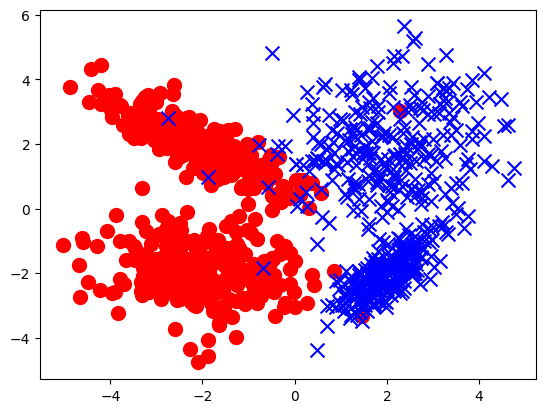

In [111]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

In [112]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters
        
    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad
    
    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b
    
    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

In [113]:
class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))
    
    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad
    
    def predict_proba(self, X):
        return self.sigmoid(X, self.b)
    
    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

In [114]:
logreg = LogReg()

X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

logreg.fit(X, y)
y_pred = logreg.predict(X)

accuracy = 0.98 F1-score = 0.98


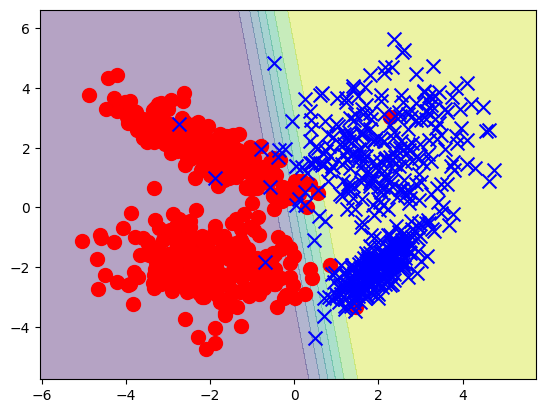

In [115]:
from sklearn.metrics import accuracy_score, f1_score
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.2f} F1-score = {f1:.2f}')

y_pred_proba = logreg.predict_proba(X)

xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01), 
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

In [116]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X, y)
y_pred_lr = model.predict(X)

## Задания для самостоятельного выполнения

#### 1. Выведите результаты работы библиотечной модели - в численном и в графическом виде.

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

model = LogisticRegression()
model.fit(X, y)

y_pred_lib = model.predict(X)

print("accuracy:", accuracy_score(y, y_pred_lib))
print("F1-score:", f1_score(y, y_pred_lib))

accuracy: 0.976
F1-score: 0.9761431411530815


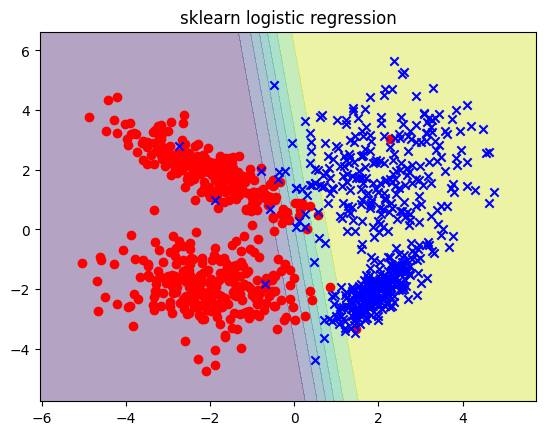

In [118]:
xx, yy = np.meshgrid(
    np.arange(X[:,1].min()-1, X[:,1].max()+1, 0.01),
    np.arange(X[:,2].min()-1, X[:,2].max()+1, 0.01)
)

grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid)[:,1]
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:,1][y==0], X[:,2][y==0], c='red', marker='o')
plt.scatter(X[:,1][y==1], X[:,2][y==1], c='blue', marker='x')
plt.title("sklearn logistic regression")
plt.show()

#### 2. Проверьте работу модели с другими значениями скорости обучения. Найдите значение, при котором градиентный спуск расходится.

In [119]:
alphas = [0.01, 0.1, 0.5, 1, 5, 10]

for a in alphas:
    model_gd = LogReg(alpha=a, n_iters=1000)
    model_gd.fit(X, y)
    y_pred = model_gd.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"alpha={a} -> accuracy={acc:.3f}")

# расходится: acc = 0.5

alpha=0.01 -> accuracy=0.973
alpha=0.1 -> accuracy=0.977
alpha=0.5 -> accuracy=0.976
alpha=1 -> accuracy=0.976
alpha=5 -> accuracy=0.976
alpha=10 -> accuracy=0.976


#### 3. Модифицируйте код модели таким образом, чтобы фиктивный столбец единиц добавлялся к матрице признаков внутри класса.

In [120]:
class LogReg(SGD):

    def __init__(self, learning_rate=0.01, n_iters=1000):
        super().__init__(learning_rate, n_iters)

    def sigmoid(self, X, b):
        return 1 / (1 + np.exp(-(X @ b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def fit(self, X, y):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.X_train = X
        self.y_train = y
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

    def predict_proba(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

model = LogReg(learning_rate=0.01, n_iters=1000)
model.fit(X, y)
accuracy = model.score(X, y)
print("accuracy:", accuracy)

accuracy: 0.972


#### 4. Поэкспериментируйте с разными значениями параметра class_sep при генерации датасета. Визуализируйте полученные распределения. Сделайте вывод о том, как этот параметр влияет на точность получаемых моделей.

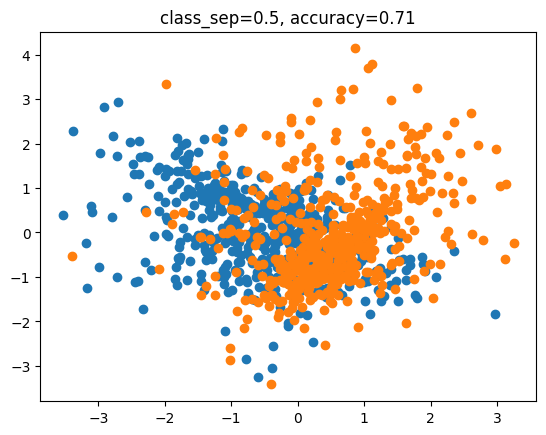

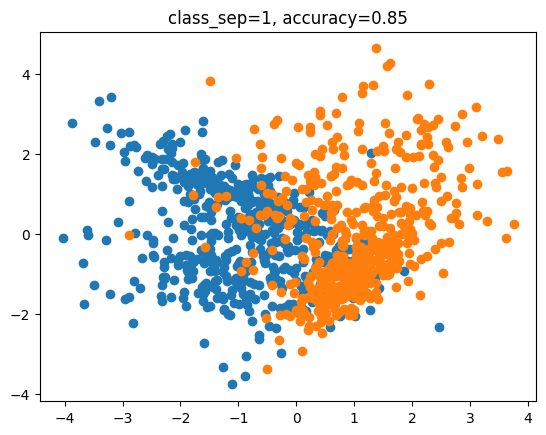

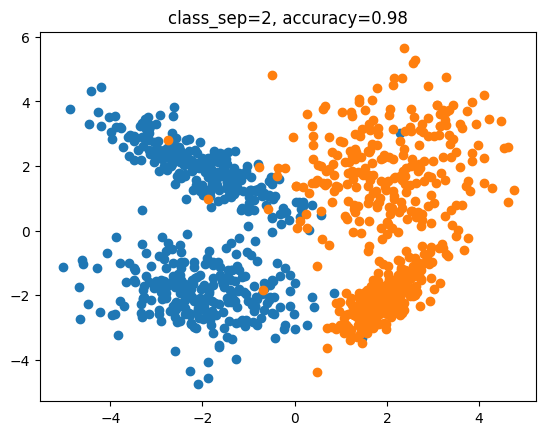

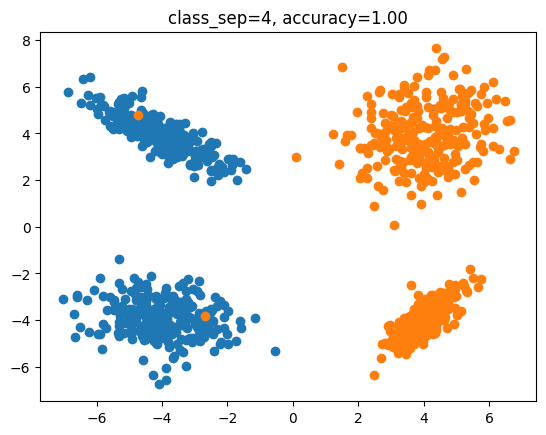

In [121]:
separations = [0.5, 1, 2, 4]

for sep in separations:
    X_sep, y_sep = make_classification(
        n_samples=1000,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_classes=2,
        class_sep=sep,
        random_state=1
    )
    
    model = LogisticRegression()
    model.fit(X_sep, y_sep)
    acc = model.score(X_sep, y_sep)
    
    plt.figure()
    plt.scatter(X_sep[:,0][y_sep==0], X_sep[:,1][y_sep==0])
    plt.scatter(X_sep[:,0][y_sep==1], X_sep[:,1][y_sep==1])
    plt.title(f"class_sep={sep}, accuracy={acc:.2f}")
    plt.show()

#### 5. Сгенерируйте датасет с большим числом признаков и примените к нему созданную модель.

In [122]:
X_big, y_big = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_classes=2,
    random_state=1
)

logreg_big = LogReg(learning_rate=0.1, n_iters=1000)
logreg_big.fit(X_big, y_big)

y_pred_big = logreg_big.predict(X_big)

print("accuracy:", accuracy_score(y_big, y_pred_big))
print("F1-score:", f1_score(y_big, y_pred_big))

accuracy: 0.899
F1-score: 0.9006882989183874


#### 6. Сгенерируйте датасет с большим количеством классов и реализуйте в классе алгоритм "один против всех". Решите задачу множественной классификации средствами sklearn.

In [123]:
X_multi, y_multi = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=5,
    n_classes=3,
    n_redundant=0,
    random_state=1
)

In [124]:
from sklearn.multiclass import OneVsRestClassifier

ovr = OneVsRestClassifier(LogisticRegression())
ovr.fit(X_multi, y_multi)
y_pred_multi = ovr.predict(X_multi)
print("accuracy:", accuracy_score(y_multi, y_pred_multi))

accuracy: 0.69


#### 7. Выведите значения вероятностей для каждого объекта принадлежать тому или иному классу для библиотечной модели LogisticRegression.

In [125]:
model = LogisticRegression()
model.fit(X, y)
probs = model.predict_proba(X)
print("5 probability rows:")
print(probs[:5])

5 probability rows:
[[3.72871543e-03 9.96271285e-01]
 [9.86153723e-01 1.38462769e-02]
 [7.93051297e-01 2.06948703e-01]
 [9.99329482e-01 6.70517810e-04]
 [5.01574404e-07 9.99999498e-01]]
